In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df  =pd.read_csv('placement.csv')
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


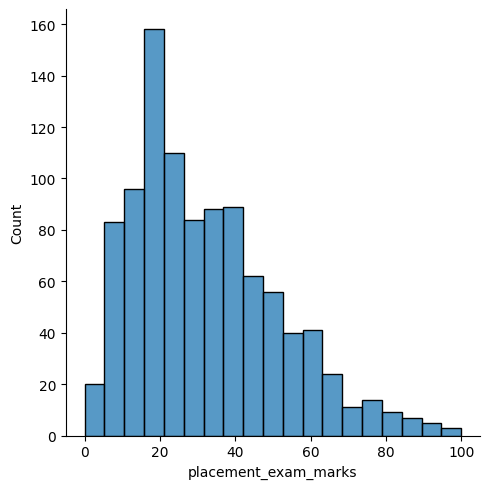

In [22]:

sns.displot(df['placement_exam_marks'])

In [23]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

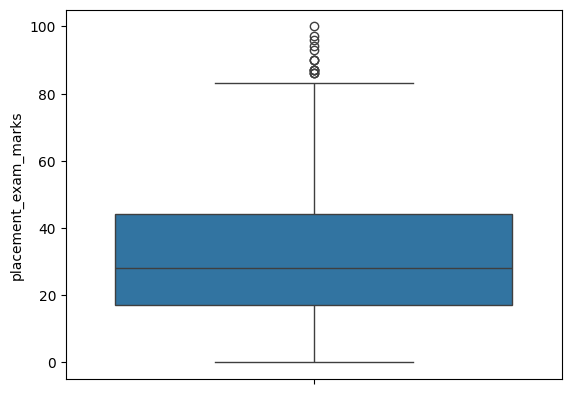

In [24]:
sns.boxplot(df['placement_exam_marks'])

In [25]:
#finding iqr

percentile75 = df['placement_exam_marks'].quantile(0.75)
percentile25 = df['placement_exam_marks'].quantile(0.25)

In [26]:
iqr = percentile75 -percentile25


In [27]:
upperLimit = percentile75+iqr*1.5
lowerLimit = percentile25-iqr*1.5

print("upperLimit",upperLimit,'\n',"lowerLimit",lowerLimit)

upperLimit 84.5 
 lowerLimit -23.5


<Axes: ylabel='placement_exam_marks'>

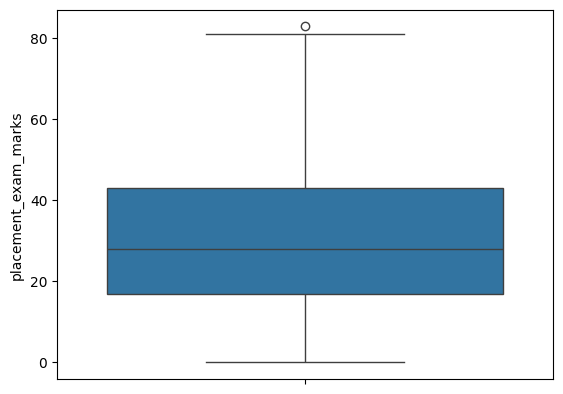

In [28]:
#trimming
new_df = df[df['placement_exam_marks']<=upperLimit]
sns.boxplot(new_df['placement_exam_marks'])

<Axes: ylabel='placement_exam_marks'>

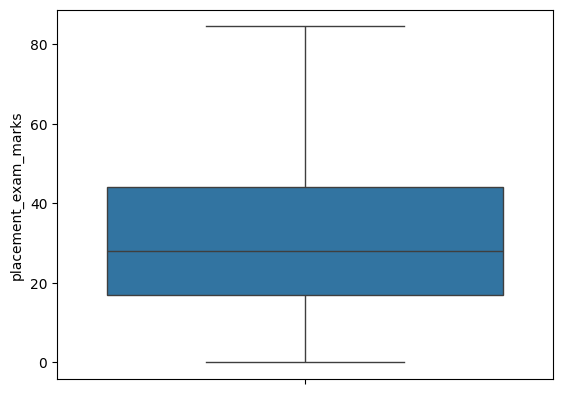

In [32]:
newdf2 = df.copy()
newdf2['placement_exam_marks'] = np.where(
    newdf2['placement_exam_marks'] > upperLimit,
    upperLimit,
    np.where(
        newdf2['placement_exam_marks']<lowerLimit,
        lowerLimit,
        newdf2['placement_exam_marks']
    )
)

sns.boxplot(newdf2['placement_exam_marks'])